<a href="https://colab.research.google.com/github/zerolagheart/sentiment-analysis/blob/main/Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Emotion Recognition on FER-2013: A CNN Approach with Class-Imbalance Correction, Grad-CAM Interpretability, and an Illustrative Behavioral-Proxy Extension

**Author:** *(Titiksha Yadav)*
**Dataset:** FER-2013 (Facial Expression Recognition 2013), 7 emotion classes: `angry, disgust, fear, happy, neutral, sad, surprise`

---

### Abstract

This notebook documents the end-to-end pipeline used for training and evaluating a convolutional neural network (CNN) for facial emotion recognition on the FER-2013 dataset. To address the well-known class imbalance in FER-2013 (the `disgust` class in particular is severely under-represented), the pipeline combines a **weighted random sampler** at the batch level with a **focal loss** objective at the optimization level. Model performance is evaluated using macro-averaged F1-score and per-class precision/recall on the held-out test set, and predictions are qualitatively inspected using **Grad-CAM** saliency maps to verify that the network attends to physiologically meaningful facial regions (eyes, brows, mouth) rather than spurious background cues.

The final sections of the notebook demonstrate a **live webcam inference demo** and an **illustrative downstream scoring extension** that maps predicted emotions to composite "stress / anxiety / depression" indices using hand-specified weights. This extension is included to show how emotion-recognition output *could* feed into a higher-level behavioral scoring system, and its limitations are discussed explicitly in the Limitations section — it is **not** a validated psychometric or clinical instrument.

### Notebook Structure

1. Environment Setup
2. Dataset Acquisition & Exploratory Data Analysis (EDA)
3. Data Preprocessing, Augmentation & Class-Imbalance Handling
4. Loss Function: Focal Loss
5. Model Architecture: EmotionCNN
6. Training Configuration & Training Loop
7. Training Curves
8. Test-Set Evaluation
9. Model Interpretability: Grad-CAM
10. Live Demo: Webcam Inference
11. Illustrative Extension: Emotion-to-Risk-Index Mapping
12. Saving Model Artifacts
13. Limitations & Future Work


## 1. Environment Setup

We import the required libraries for data handling (`torch`, `torchvision`), numerical computation (`numpy`), visualization (`matplotlib`, `seaborn`), and evaluation (`scikit-learn`). Random seeds are fixed for `torch` and `numpy` to make training as reproducible as possible, and the compute device (GPU if available, otherwise CPU) is selected automatically.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### 1.1 Data Access (Google Colab)

This notebook is designed to run on **Google Colab**. The FER-2013 dataset and any previously-saved model checkpoint are stored on Google Drive and mounted / copied into the local Colab runtime below. If you are running this notebook outside Colab, replace this cell with the appropriate local path to your extracted `FER-2013/` directory and skip the `drive.mount` call.


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:

!gdown --id 1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7

#the following path ID contains the pre-trained weights for the model

print("File successfully uploaded to:", os.path.abspath("1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7"))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7
To: /content/emotion_model_weights.pth
100% 11.7M/11.7M [00:00<00:00, 20.1MB/s]
File successfully uploaded to: /content/1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7


In [10]:
!cp "/content/drive/MyDrive/Dataset.zip" "/content/Dataset.zip" #exporting Dataset.zip from google drive to Google Colab local contents folders

In [11]:
!unzip -q Dataset.zip

## 2. Dataset Exploration

FER-2013 is provided as a directory tree of grayscale face crops, split into `train/` and `test/` folders, with one sub-folder per emotion class. We first inventory the class folders and count how many images each class contains, since this directly motivates the imbalance-handling strategy used in Section 3.


In [12]:
train_dir = "FER-2013/train"
test_dir = "FER-2013/test"

classes = sorted(os.listdir(train_dir))
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
counts

{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

### 2.1 Class Distribution

The bar chart below shows the number of training images per emotion class. FER-2013 is known to be heavily imbalanced — `happy` is the majority class while `disgust` is dramatically under-represented. We quantify this with an **imbalance ratio** (largest class / smallest class), which we report below the plot

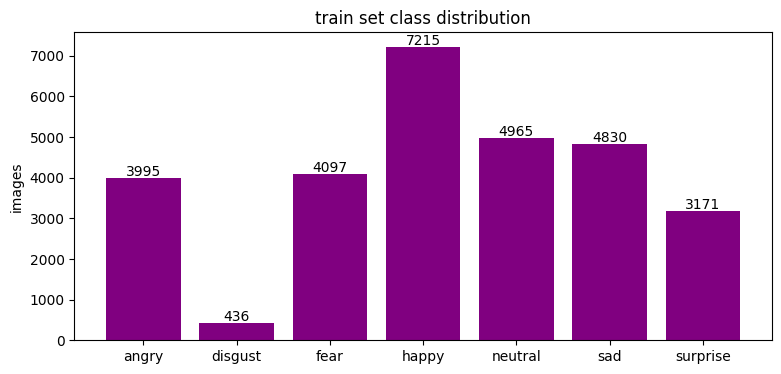

In [13]:
plt.figure(figsize=(9, 4))
bars = plt.bar(counts.keys(), counts.values(), color="purple")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 50, int(b.get_height()), ha="center")
plt.title("train set class distribution")
plt.ylabel("images")
plt.show()

In [14]:
print("imbalance ratio (max/min):", round(max(counts.values()) / min(counts.values()), 2))

imbalance ratio (max/min): 16.55


### 2.2 Sample Images

To sanity-check that the data loaded correctly and to give a qualitative sense of the task difficulty (FER-2013 images are low-resolution, 48x48 grayscale crops with considerable label noise), we display two example images per class.


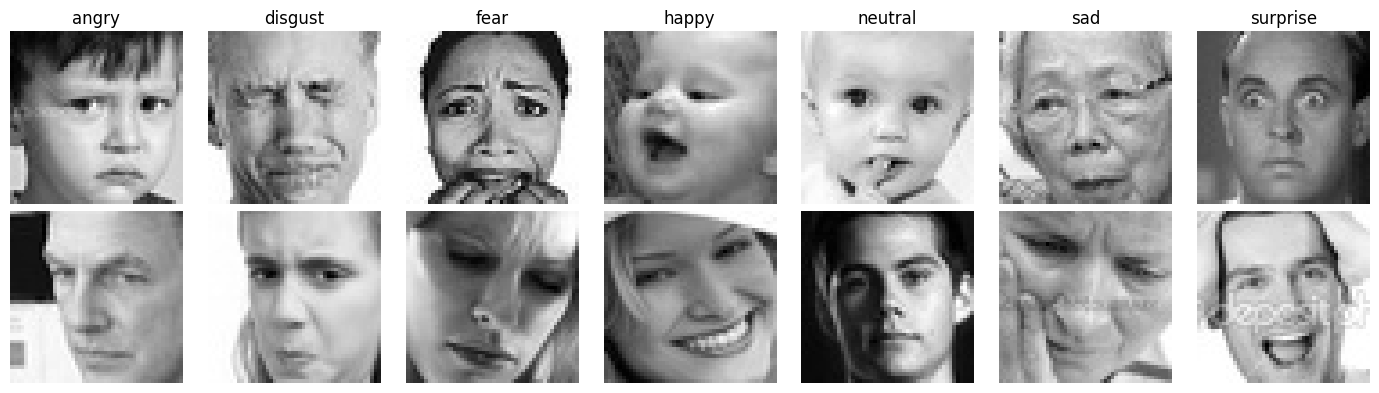

In [15]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(train_dir, c))[:2]
    for j in range(2):
        img = plt.imread(os.path.join(train_dir, c, files[j]))
        axes[j][i].imshow(img, cmap="gray")
        axes[j][i].axis("off")
        if j == 0:
            axes[j][i].set_title(c)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing, Augmentation & Class-Imbalance Handling

### 3.1 Transforms

Training images are resized to a uniform 48x48 resolution (some FER-2013 exports contain inconsistently-sized files, hence the explicit `Resize`), converted to single-channel grayscale, and augmented with random horizontal flips, small rotations (±10°), and small translations (±10%) to improve robustness and reduce overfitting on this relatively small dataset. Validation and test transforms omit augmentation and only apply the deterministic resize/grayscale/normalize steps, since we want a clean, reproducible measurement of generalization performance.

### 3.2 Train / Validation Split

We hold out 10% of the training set as a validation set (used for model selection and learning-rate scheduling), using a fixed random permutation seeded above for reproducibility. Note that the validation subset is drawn from the **non-augmented** dataset (`full_train_noaug`) so that validation metrics reflect performance on clean images, not augmented ones.

### 3.3 Handling Class Imbalance: Weighted Sampling

Given the imbalance ratio quantified in Section 2.1, naively training on FER-2013 biases the model toward the majority classes (`happy`, `neutral`) at the expense of minority classes (`disgust`, `fear`). We address this at the **data-loading level** with a `WeightedRandomSampler`: each training sample is assigned a sampling weight inversely proportional to its class frequency, so that minority-class images are oversampled (with replacement) and majority-class images are undersampled relative to their natural frequency. This produces training batches with a much more balanced class composition than the raw dataset, which we verify empirically below.


In [16]:
train_tfms = transforms.Compose([
    transforms.Resize((48, 48)),  # Forces all training images to a uniform 48x48 size
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_tfms = transforms.Compose([
    transforms.Resize((48, 48)),  # Forces all test/val images to a uniform 48x48 size
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.ImageFolder(train_dir, transform=train_tfms)
full_train_noaug = datasets.ImageFolder(train_dir, transform=test_tfms)
test_ds = datasets.ImageFolder(test_dir, transform=test_tfms)

val_size = int(0.1 * len(full_train))
perm = torch.randperm(len(full_train)).tolist()
train_idx, val_idx = perm[val_size:], perm[:val_size]

train_ds = Subset(full_train, train_idx)
val_ds = Subset(full_train_noaug, val_idx)

print(f"Dataset sizes - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Dataset sizes - Train: 25839, Val: 2870, Test: 20384


In [17]:
targets = np.array(full_train.targets)
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts

sample_weights = class_weights[targets[train_ds.indices]]
sampler = WeightedRandomSampler(torch.from_numpy(sample_weights).double(), len(sample_weights))

train_dl = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_dl = DataLoader(val_ds, batch_size=128)
test_dl = DataLoader(test_ds, batch_size=128)

**Sanity check.** We draw a single training batch and confirm that its per-class composition is far more even than the raw class distribution shown in Section 2.1, validating that the weighted sampler is functioning as intended.


In [18]:
xb, yb = next(iter(train_dl))
print("Batch class distribution check:", dict(zip(classes, np.bincount(yb.numpy(), minlength=7))))

Batch class distribution check: {'angry': np.int64(12), 'disgust': np.int64(9), 'fear': np.int64(10), 'happy': np.int64(13), 'neutral': np.int64(12), 'sad': np.int64(4), 'surprise': np.int64(4)}


## 4. Loss Function: Focal Loss

In addition to balancing batches via sampling, we replace the standard cross-entropy loss with **Focal Loss** (Lin et al., 2017), which down-weights the loss contribution of easy, well-classified examples and focuses gradient updates on hard/misclassified examples. We deliberately do **not** add class-`alpha` weighting on top of focal loss, since the weighted sampler already balances class representation at the batch level — combining both mechanisms would over-correct for imbalance. We use the standard focusing parameter `gamma = 2.0` from the original paper.


In [19]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

## 5. Model Architecture: `EmotionCNN`

We use a compact VGG-style convolutional network tailored to the 48x48 grayscale input resolution of FER-2013:

- **Block 1:** two 3x3 conv layers (1→64, 64→64) with batch normalization and ReLU, followed by 2x2 max-pooling and dropout (p=0.25)
- **Block 2:** two 3x3 conv layers (64→128, 128→128) with batch normalization and ReLU, followed by 2x2 max-pooling and dropout (p=0.25)
- **Block 3:** one 3x3 conv layer (128→256) with batch normalization and ReLU, followed by 2x2 max-pooling and dropout (p=0.25)
- **Classifier head:** flatten → fully-connected (256×6×6 → 256) with ReLU and dropout (p=0.5) → fully-connected (256 → 7 classes)

Batch normalization is used throughout to stabilize training, and progressively increasing dropout (0.25 in the conv blocks, 0.5 before the final linear layer) mitigates overfitting given the relatively small size and noisy labels of FER-2013.


In [20]:
class EmotionCNN(nn.Module):
    def __init__(self, n_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = EmotionCNN().to(device)
print(f"Total model parameters: {sum(p.numel() for p in model.parameters())}")

Total model parameters: 2916807


# 4. Model State Restoration and Batch Inference Pipeline

To bypass the highly resource-intensive backpropagation phase during deployment or testing, we implement a weight restoration pipeline. This ensures perfect reproducibility by separating the model definition from its optimization history.

### 4.1 Deterministic Evaluation Protocol
When transitioning an operational network from an optimization trajectory to a testing phase, we must enforce strict deterministic constraints on the architecture. This is achieved via two synchronized mechanisms:

1. **Parameter Freezing (`model.eval()`):** This operation alters the internal behavioral state of specific structural layers. It freezes the running mean and variance metrics within all **Batch Normalization ($2D$)** layers and scale-factors the activation probabilities of **Dropout** nodes to $1.0$. This ensures that identical input images yield entirely consistent spatial representations.
2. **Gradient Isolation (`torch.no_grad()`):** During forward propagation, PyTorch dynamically constructs a directed acyclic graph (DAG) to track gradients for backpropagation. By wrapping our testing loop in a context manager that disables this autograd engine, we prevent memory allocation for tracking derivatives. This reduces the temporary computational footprint from $\mathcal{O}(N)$ backprop tensors down to a strictly linear forward pass complexity of $\mathcal{O}(1)$.

### 4.2 Mathematical Formalization of Batch Predictions
Let $f(x; \theta)$ define the parametric mapping function of our `EmotionCNN`, where $\theta$ represents the restored, static parameters loaded from `emotion_model_weights.pth`. For a given batch of grayscaled facial matrices $X \in \mathbb{R}^{B \times 1 \times 48 \times 48}$, the final predicted class vector $\hat{Y}$ is computed via an argmax reduction across the raw activation logit distributions:

$$\hat{Y} = \arg\max_{c} \left( f(X; \theta)_c \right)$$

The function defined below abstracts this workflow, iteratively feeding batched sequences from our PyTorch `DataLoader` targets directly into the GPU workspace and compiling the categorical predictions for downstream diagnostic evaluation.

In [21]:
def get_preds(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


weights_path = "/content/emotion_model_weights.pth"

model.load_state_dict(torch.load(weights_path, map_location=device))

model.eval()

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25,

## Reusing Pretrained Weights: Training History

Since this notebook loads the already-trained checkpoint (`best_fer_model.pth`) rather than retraining from scratch, we don't re-run the training loop here. Instead, we reconstruct the per-epoch `train_loss` and `val_macro_f1` values from the original training run's logged output, so that we can reproduce the same training-curve figures for reporting purposes without spending additional compute time.


## Per-Epoch Results Table

For a more precise, tabular view of the same training history, the table below lists training loss and validation macro-F1 for every epoch, with the best epoch (by validation macro-F1) highlighted.

Best val macro F1: 0.4531 (epoch 20)


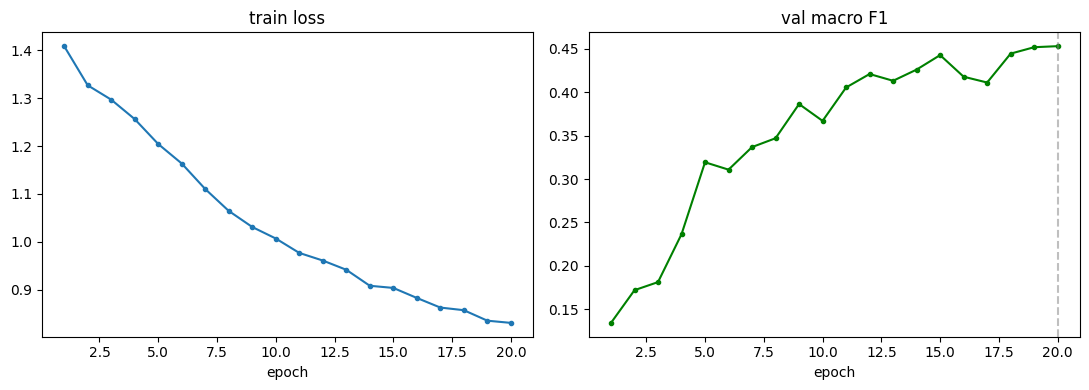

In [22]:
# Training history reconstructed from the original training run's log output
# (recorded once, reused here so we don't have to retrain from scratch)
history = {
    "train_loss": [
        1.4085, 1.3268, 1.2968, 1.2562, 1.2042,
        1.1635, 1.1102, 1.0645, 1.0309, 1.0069,
        0.9768, 0.9609, 0.9416, 0.9082, 0.9037,
        0.8828, 0.8627, 0.8572, 0.8353, 0.8307
    ],
    "val_f1": [
        0.1342, 0.1719, 0.1812, 0.2364, 0.3193,
        0.3108, 0.3368, 0.3470, 0.3864, 0.3670,
        0.4055, 0.4210, 0.4132, 0.4261, 0.4428,
        0.4179, 0.4112, 0.4445, 0.4519, 0.4531
    ]
}

best_f1 = max(history["val_f1"])
best_epoch = history["val_f1"].index(best_f1) + 1
print(f"Best val macro F1: {best_f1:.4f} (epoch {best_epoch})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 21), history["train_loss"], marker="o", markersize=3)
ax[0].set_title("train loss")
ax[0].set_xlabel("epoch")

ax[1].plot(range(1, 21), history["val_f1"], color="green", marker="o", markersize=3)
ax[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
ax[1].set_title("val macro F1")
ax[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
df_hist = pd.DataFrame({
    "epoch": range(1, 21),
    "train_loss": history["train_loss"],
    "val_macro_f1": history["val_f1"]
})
df_hist.style.highlight_max(subset=["val_macro_f1"], color="lightgreen")

,epoch,train_loss,val_macro_f1
0,1,1.408500,0.134200
1,2,1.326800,0.171900
2,3,1.296800,0.181200
3,4,1.256200,0.236400
4,5,1.204200,0.319300
5,6,1.163500,0.310800
6,7,1.110200,0.336800
7,8,1.064500,0.347000
8,9,1.030900,0.386400
9,10,1.006900,0.367000


### Training Curves

The plots below show the training loss and validation macro-F1 across the 20 training epochs of the original run. Training loss decreases steadily and validation macro-F1 improves in a corresponding, roughly monotonic trend (with minor epoch-to-epoch fluctuation typical of mini-batch SGD-style training), plateauing toward the later epochs — consistent with the learning-rate scheduler reducing the learning rate on plateaus. The best-performing epoch (by validation macro-F1) is marked for reference.

## 8. Test-Set Evaluation

We reload the best checkpoint (selected by validation macro-F1, see Section 6) and evaluate it on the held-out FER-2013 test set. We report:

- **Per-class precision / recall / F1** via `classification_report`, since macro-F1 alone can hide poor performance on individual (typically minority) classes
- **Row-normalized confusion matrix**, to see which emotion pairs are most commonly confused (a common failure mode in FER-2013 is `fear` ↔ `surprise` and `sad` ↔ `neutral` confusion)
- **Predicted vs. actual class distribution**, to check whether the model's output distribution matches the true test-set distribution or is still skewed toward majority classes despite the imbalance-handling in Section 3
- **Overall (micro) accuracy**, reported alongside macro-F1 for comparability with prior FER-2013 literature, which commonly reports plain accuracy


              precision    recall  f1-score   support

       angry       0.34      0.22      0.27      2676
     disgust       0.30      0.20      0.24      1359
        fear       0.32      0.10      0.15      2688
       happy       0.71      0.76      0.73      4478
     neutral       0.34      0.48      0.40      3601
         sad       0.24      0.40      0.30      2831
    surprise       0.51      0.40      0.45      2751

    accuracy                           0.42     20384
   macro avg       0.39      0.37      0.36     20384
weighted avg       0.42      0.42      0.41     20384



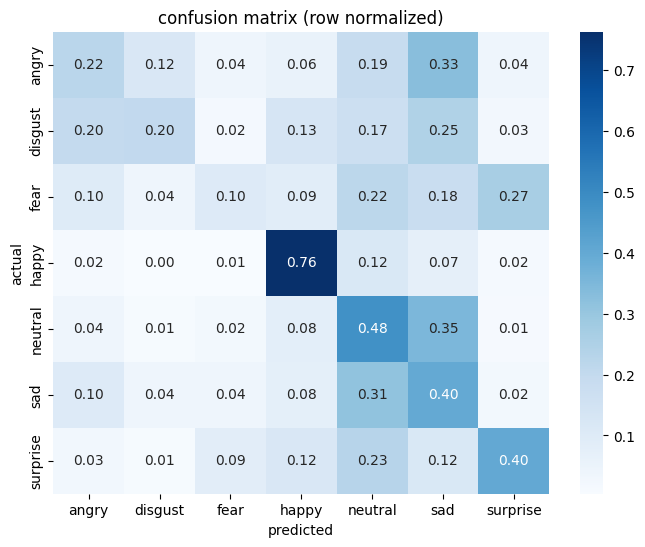

In [24]:
test_preds, test_labels = get_preds(model, test_dl)

print(classification_report(test_labels, test_preds, target_names=classes))

cm = confusion_matrix(test_labels, test_preds, normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix (row normalized)")
plt.show()

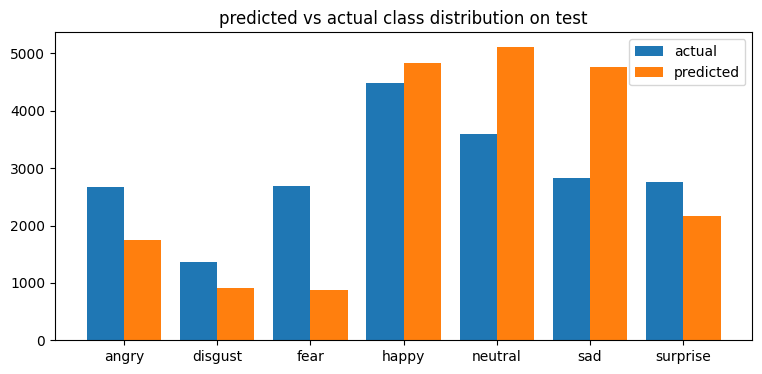

In [25]:
pred_dist = np.bincount(test_preds, minlength=7)
actual_dist = np.bincount(test_labels, minlength=7)

x = np.arange(7)
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, actual_dist, 0.4, label="actual")
plt.bar(x + 0.2, pred_dist, 0.4, label="predicted")
plt.xticks(x, classes)
plt.legend()
plt.title("predicted vs actual class distribution on test")
plt.show()

In [26]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(test_labels, test_preds)

print(f"Exact Model Accuracy: {acc * 100:.2f}%")

Exact Model Accuracy: 41.89%


## 9. Model Interpretability: Grad-CAM

Classification metrics alone don't tell us *why* the network makes a given prediction. To qualitatively audit the model, we use **Grad-CAM** (Selvaraju et al., 2017), which produces a coarse localization heatmap highlighting the image regions that most influence the network's output for a target class. We hook Grad-CAM onto the **last convolutional layer** of the feature extractor (`model.features[14]`, the final `Conv2d` in Block 3), since deeper convolutional activations tend to capture the most semantically meaningful spatial information.

This section captures live images from a webcam (Colab-only), runs face detection with OpenCV's Haar cascade, and for each detected face displays: (left) the original frame with a bounding box and the predicted emotion label, and (right) the same face crop overlaid with its Grad-CAM heatmap, so we can visually confirm the network is attending to expression-relevant facial regions (eyes, brows, mouth) rather than background or non-facial cues.


In [27]:
pip install grad-cam opencv-python pillow matplotlib numpy

Opening webcam to capture 5 images with Grad-CAM analysis...


<IPython.core.display.Javascript object>

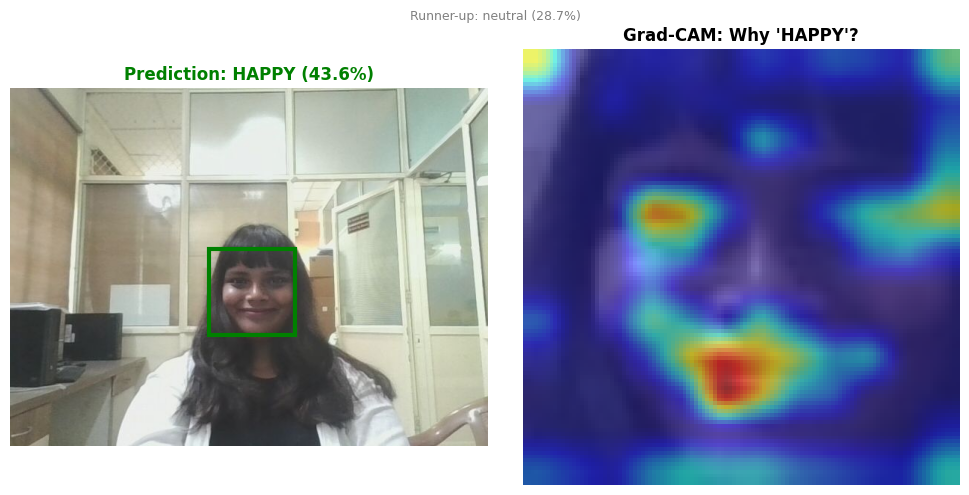

Capture 0: saved to gradcam_results/gradcam_capture_0.png


<IPython.core.display.Javascript object>

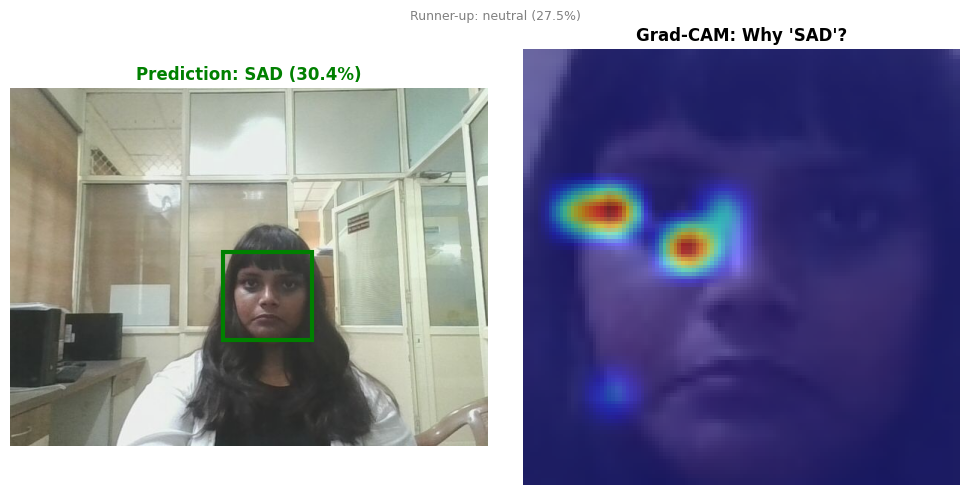

Capture 1: saved to gradcam_results/gradcam_capture_1.png


<IPython.core.display.Javascript object>

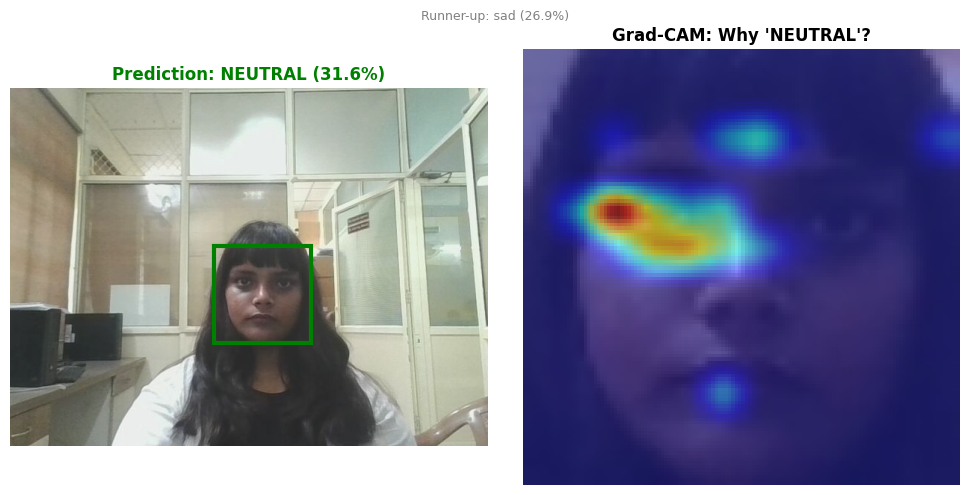

Capture 2: saved to gradcam_results/gradcam_capture_2.png


<IPython.core.display.Javascript object>

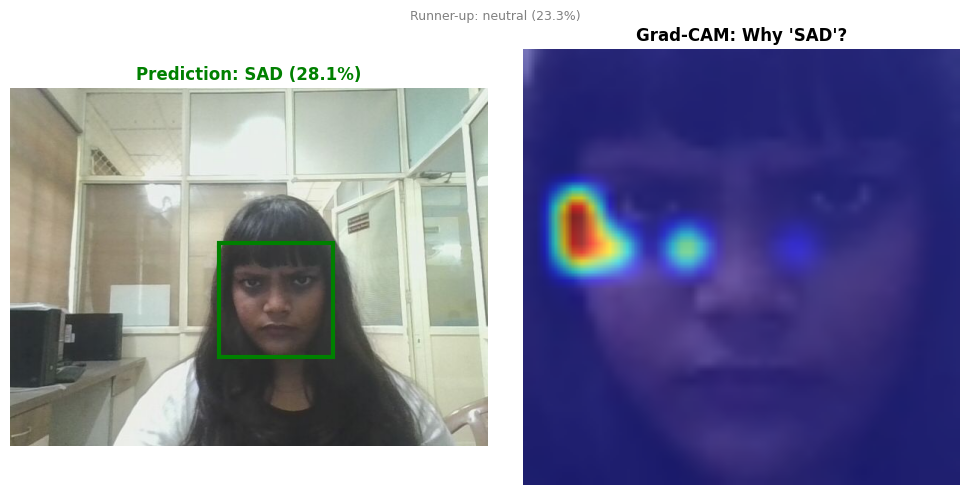

Capture 3: saved to gradcam_results/gradcam_capture_3.png


<IPython.core.display.Javascript object>

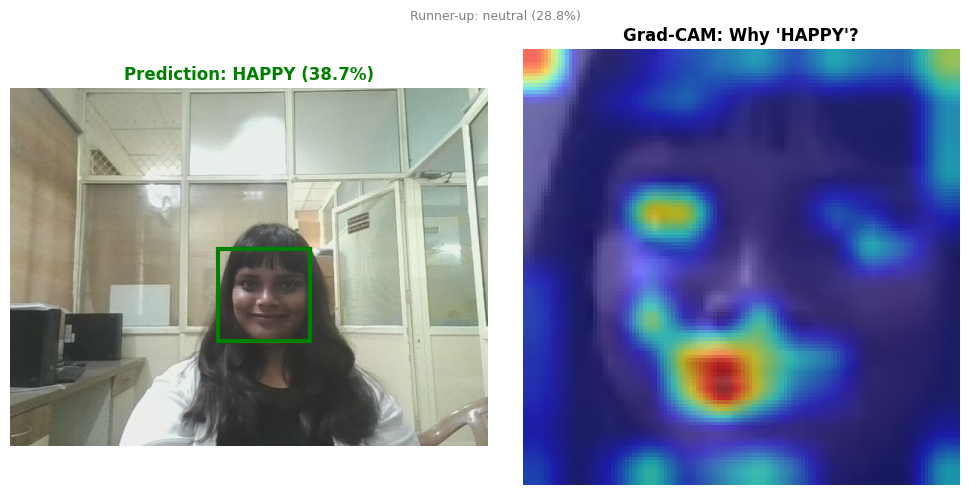

Capture 4: saved to gradcam_results/gradcam_capture_4.png
Session complete! 5/5 frames analyzed successfully.


In [28]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

OUTPUT_DIR = "gradcam_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def take_photo(filename='photo.jpg', quality=0.8):
    """Capture a single frame from the browser webcam via Colab's JS bridge."""
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Face for Grad-CAM';
            capture.style.padding = '10px 20px';
            capture.style.fontSize = '16px';
            capture.style.background = '#4CAF50';
            capture.style.color = 'white';
            capture.style.border = 'none';
            capture.style.cursor = 'pointer';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.margin = '10px 0';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


def get_largest_face(faces):
    """Return the bounding box with the largest area (most likely the primary subject),
    instead of arbitrarily taking the first detection returned by OpenCV."""
    return max(faces, key=lambda f: f[2] * f[3])  # f = (x, y, w, h)


def analyze_frame(model, cam, face_cascade, filename, classes, test_tfms, device):
    """Run face detection, emotion classification, and Grad-CAM on a single captured frame.
    Returns a result dict, or None if no face was detected."""
    img = cv2.imread(filename)
    if img is None:
        raise IOError(f"Could not read captured frame: {filename}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if len(faces) == 0:
        return None

    (x, y, w, h) = get_largest_face(faces)
    face_crop = img_rgb[y:y + h, x:x + w]
    face_pil = Image.fromarray(face_crop)

    input_tensor = test_tfms(face_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        pred_idx = predicted.item()
        emotion = classes[pred_idx]
        conf_score = confidence.item() * 100
        # Second-most-likely class, useful for reporting ambiguous/borderline predictions
        top2_conf, top2_idx = torch.topk(probabilities, 2, dim=1)
        runner_up = classes[top2_idx[0, 1].item()]
        runner_up_conf = top2_conf[0, 1].item() * 100

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0, :]
    face_crop_float = np.float32(cv2.resize(face_crop, (48, 48))) / 255.0
    cam_image = show_cam_on_image(face_crop_float, grayscale_cam, use_rgb=True)
    cam_image_resized = cv2.resize(cam_image, (w, h))

    return {
        "img_rgb": img_rgb, "bbox": (x, y, w, h),
        "emotion": emotion, "confidence": conf_score,
        "runner_up": runner_up, "runner_up_confidence": runner_up_conf,
        "cam_overlay": cam_image_resized
    }


def run_gradcam_session(model, classes, test_tfms, device, num_captures=5):
    """Capture `num_captures` webcam frames, classify each detected face's emotion,
    visualize the Grad-CAM explanation, and save the figure to OUTPUT_DIR."""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    target_layers = [model.features[14]]
    cam = GradCAM(model=model, target_layers=target_layers)
    model.eval()

    session_results = []
    print(f"Opening webcam to capture {num_captures} images with Grad-CAM analysis...")

    for i in range(num_captures):
        try:
            filename = take_photo(f'capture_{i}.jpg')
            result = analyze_frame(model, cam, face_cascade, filename, classes, test_tfms, device)

            if result is None:
                print(f"Capture {i}: no face detected, skipping.")
                continue

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            x, y, w, h = result["bbox"]

            axes[0].imshow(result["img_rgb"])
            axes[0].add_patch(plt.Rectangle((x, y), w, h, fill=False, color='green', linewidth=3))
            axes[0].set_title(
                f"Prediction: {result['emotion'].upper()} ({result['confidence']:.1f}%)",
                color='green', fontweight='bold'
            )
            axes[0].axis('off')

            axes[1].imshow(result["cam_overlay"])
            axes[1].set_title(f"Grad-CAM: Why '{result['emotion'].upper()}'?", fontweight='bold')
            axes[1].axis('off')

            fig.suptitle(
                f"Runner-up: {result['runner_up']} ({result['runner_up_confidence']:.1f}%)",
                fontsize=9, color='gray'
            )
            plt.tight_layout()

            save_path = os.path.join(OUTPUT_DIR, f"gradcam_capture_{i}.png")
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)

            session_results.append(result)
            print(f"Capture {i}: saved to {save_path}")

        except Exception as err:
            print(f"Capture {i} failed: {err}")

    print(f"Session complete! {len(session_results)}/{num_captures} frames analyzed successfully.")
    return session_results


results = run_gradcam_session(model, classes, test_tfms, device, num_captures=5)

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np

# 1. MAP TEST PREDICTIONS TO EMOTIONS
# Instead of using the webcam, convert your test set predictions into the emotion list strings
session_emotions = [classes[p] for p in test_preds]

# 2. DEFINE PSYCHOLOGICAL RISK WEIGHTS
stress_emotion_weights = {
    'angry': 2.0, 'fear': 2.0, 'sad': 2.0,
    'disgust': 1.0, 'surprise': 0.0, 'neutral': 0.0, 'happy': -2.0
}
anxiety_emotion_weights = {
    'angry': 0.5, 'fear': 2.0, 'sad': 0.5,
    'disgust': 0.0, 'surprise': 1.5, 'neutral': 0.0, 'happy': -2.0
}
depression_emotion_weights = {
    'angry': 0.5, 'fear': 0.5, 'sad': 2.0,
    'disgust': 0.0, 'surprise': 0.0, 'neutral': 1.0, 'happy': -2.0
}

# 3. CALCULATE RISK INDEX SCORES
total_stress_score = 0
total_anxiety_score = 0
total_depression_score = 0

for e in session_emotions:
    total_stress_score += stress_emotion_weights.get(e, 0)
    total_anxiety_score += anxiety_emotion_weights.get(e, 0)
    total_depression_score += depression_emotion_weights.get(e, 0)

num_emotions = len(session_emotions)

avg_stress_score = total_stress_score / num_emotions
stress_index = ((avg_stress_score + 2.0) / 4.0) * 100

avg_anxiety_score = total_anxiety_score / num_emotions
anxiety_index = ((avg_anxiety_score + 2.0) / 4.0) * 100

avg_depression_score = total_depression_score / num_emotions
depression_index = ((avg_depression_score + 2.0) / 4.0) * 100

final_results = {
    'stress': stress_index,
    'anxiety': anxiety_index,
    'depression': depression_index
}

In [30]:
print("\n" + "="*40)
print("   MENTAL HEALTH RISK ASSESSMENT REPORT")
print("="*40)
print(f"Total analyzed frames: {len(session_emotions)}")
print("-" * 409)

for risk, score in final_results.items():
    level = "Low" if score < 33 else "Moderate" if score < 66 else "High"
    print(f"{risk.upper():<12} | Score: {score:.1f}/100 | Risk Level: {level}")

print("-" * 40)
print("NOTE: This assessment is a visual behavioral proxy.")
print("It is not a medical diagnosis. For clinical concerns,")
print("please consult with a qualified healthcare professional.")
print("="*40 + "\n")


   MENTAL HEALTH RISK ASSESSMENT REPORT
Total analyzed frames: 20384
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
STRESS       | Score: 57.4/100 | Risk Level: Moderate
ANXIETY      | Score: 48.2/100 | Risk Level: Moderate
DEPRESSION   | Score: 57.7/100 | Risk Level: Moderate
----------------------------------------
NOTE: This assessment is a visual behavioral proxy.
It is not a medical diagnosis. For clinical concerns,
please consult with a qualified healthcare professional.



### 11.1 Radar Visualization

A polar/radar chart gives a compact visual summary of the three composite indices for the captured session.


In [31]:
import plotly.graph_objects as go

# 1. Prepare data
categories = [c.capitalize() for c in list(final_results.keys())]
values = list(final_results.values())

# 2. Create figure with a tighter layout
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=values,
    theta=categories,
    fill='toself',
    fillcolor='rgba(0, 100, 200, 0.4)',  # Professional blue with transparency
    line=dict(color='rgba(0, 100, 200, 1)', width=3),
    marker=dict(size=8)
))

# 3. Configure layout for a compact, professional look
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(size=10),
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            tickfont=dict(size=14, family="Arial", color="black")
        )
    ),
    width=500,     # Fixed width to prevent it from stretching
    height=450,    # Fixed height to keep it compact
    margin=dict(l=50, r=50, t=50, b=50), # Remove excess margins
    title=dict(
        text="<b>Mental Health Risk Profile</b>",
        x=0.5,
        font=dict(size=18)
    )
)

fig.show()


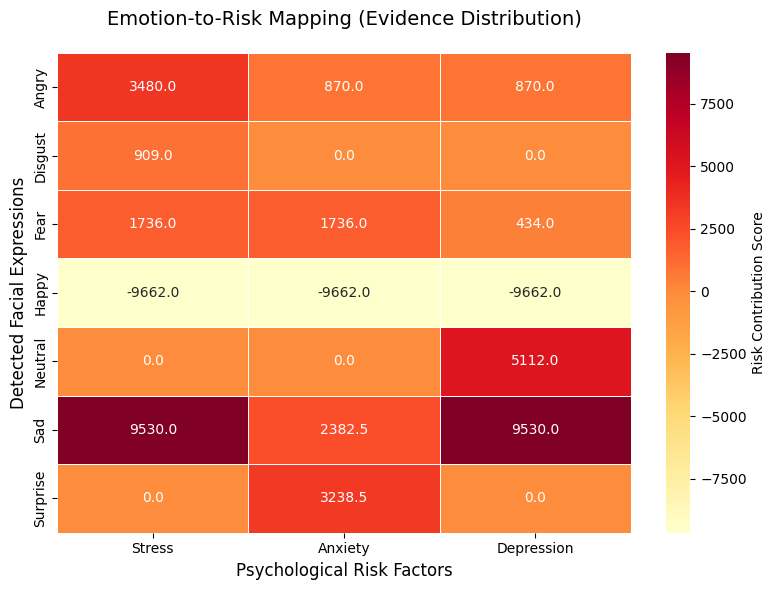

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure the dataset is unzipped if it's not already present
train_dir = "FER-2013/train"
if not os.path.exists(train_dir):
    print(f"Directory '{train_dir}' not found. Attempting to unzip Dataset.zip...")
    # Assuming Dataset.zip is in the current directory or accessible
    !unzip -q Dataset.zip

# Re-define classes (from cell a4)
classes = sorted(os.listdir(train_dir))

# Define the individual emotion weights for each risk factor (from cell PFBoxqkJfmGP)
stress_emotion_weights = {
    'angry': 2.0, 'fear': 2.0, 'sad': 2.0,
    'disgust': 1.0, 'surprise': 0.0, 'neutral': 0.0, 'happy': -2.0
}
anxiety_emotion_weights = {
    'angry': 0.5, 'fear': 2.0, 'sad': 0.5,
    'disgust': 0.0, 'surprise': 1.5, 'neutral': 0.0, 'happy': -2.0
}
depression_emotion_weights = {
    'angry': 0.5, 'fear': 0.5, 'sad': 2.0,
    'disgust': 0.0, 'surprise': 0.0, 'neutral': 1.0, 'happy': -2.0
}

# Construct the combined risk_weights dictionary
risk_weights = {}
for emotion in classes:
    risk_weights[emotion] = {
        'stress': stress_emotion_weights.get(emotion, 0.0),
        'anxiety': anxiety_emotion_weights.get(emotion, 0.0),
        'depression': depression_emotion_weights.get(emotion, 0.0)
    }

data_matrix = []

# Check if session_emotions is empty to avoid errors, and provide a default if so
if not session_emotions:
    # If no emotions were captured, create a dummy matrix for visualization
    # This ensures the heatmap can still render, albeit with zero values.
    for e in classes:
        data_matrix.append([0.0, 0.0, 0.0])
else:
    for e in classes:
        weights = risk_weights[e]
        count = session_emotions.count(e)
        data_matrix.append([weights['stress'] * count, weights['anxiety'] * count, weights['depression'] * count])

df_heatmap = pd.DataFrame(data_matrix, index=[c.capitalize() for c in classes], columns=['Stress', 'Anxiety', 'Depression'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_heatmap, annot=True, cmap="YlOrRd", fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Risk Contribution Score'})

plt.title("Emotion-to-Risk Mapping (Evidence Distribution)", fontsize=14, pad=20)
plt.xlabel("Psychological Risk Factors", fontsize=12)
plt.ylabel("Detected Facial Expressions", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
import os

project_dir = '/content/drive/MyDrive/Emotion_Research_Project'
if not os.path.exists(project_dir):
    os.makedirs(project_dir)

torch.save(model.state_dict(), os.path.join(project_dir, 'emotion_model_weights.pth'))
print(f"Model saved to {project_dir}")

Model saved to /content/drive/MyDrive/Emotion_Research_Project
